## Run InferAGNI static retrievals for comparison against BayesOpt evolution

In [1]:
import os
nthreads = 1
os.environ["OMP_NUM_THREADS"] = str(nthreads)
os.environ["OPENBLAS_NUM_THREADS"] = str(nthreads)
os.environ["MKL_NUM_THREADS"] = str(nthreads)

In [2]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import os
import json
import toml
from scipy.interpolate import PchipInterpolator

import matplotlib as mpl
font = {'family' : 'sans',
        'size'   : 12}

abcd = "abcdefghijklmnopqrstuvwxyz"

mpl.rc('font', **font)
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, LogLocator, MaxNLocator
import matplotlib.pyplot as plt

from copy import deepcopy


import matplotlib.patheffects as pe

import pandas as pd
from cmcrameri import cm

from scipy.stats import gaussian_kde


DPI = 400


import inferagni as ia
from inferagni.plot import load_melting_data, calc_Tdemix, truth_color

from inferagni.retrieve import run_retrieval, plot_corner, plot_chain

In [3]:
# THESIS_DIR = "/home2/p321409/Projects/thesis_pipeline"
# SIM_DIR = "data/scratch/"

# THESIS_DIR = "/home/harrison/Projects/thesis_pipeline"
# SIM_DIR = "data/"

THESIS_DIR = "/data/hen28/Projects/thesis_pipeline"
SIM_DIR = "data/bayesopt_recent/"

In [4]:
# %config InlineBackend.figure_format = 'retina'

In [5]:
meltcurves = load_melting_data()

In [6]:
gr = ia.grid.Grid()

Loading data from disk...
    Source: /data/hen28/Projects/InferAGNI/src/inferagni/data/grid_022
Loading grid of scalar quantities
    Grid size: 504000 points
    Input vars:
      Teff            : range [2500      , 6500      ]
      instellation    : range [1         , 1000      ]
      logZ            : range [-2        , 1         ]
      logCO           : range [-3        , 0         ]
      mass_tot        : range [1         , 10        ]
      frac_core       : range [0.2       , 0.7       ]
      frac_atm        : range [0.000562  , 0.25      ]
    Output vars: 
      succ, flux_loss_max, r_bound, p_surf,
      t_surf, r_surf, μ_surf, g_surf, t_phot,
      r_phot, μ_phot, g_phot, vmr_H2,
      vmr_H2O, vmr_CO2, vmr_CO, vmr_O2,
      vmr_OH, vmr_NH3, vmr_NO2, vmr_N2,
      vmr_SO2, vmr_H2S, vmr_H2SO4, Kzz_max,
      conv_ptop, conv_pbot, flux_loss_med,
      flux_toa, flux_boa, H_phot, log_vmr_H2,
      log_vmr_H2O, log_vmr_CO2, log_vmr_CO,
      log_vmr_O2, log_vmr_OH, log_vm

In [7]:
# map PROTEUS keys to inferAGNI observables
def key_map(ia_key, hf_row):

    match ia_key:
        case "r_phot": return hf_row["R_obs"] / ia.util.R_earth
        case "mass_tot": return hf_row["M_planet"] / ia.util.M_earth
        case "μ_phot": return hf_row["atm_kg_per_mol"] / 1e-3 # kg/mol to g/mol
        case "instellation": return hf_row["F_ins"] / ia.util.S_earth
        case "Teff": return hf_row["T_star"] / 1.0
        case "frac_atm": return hf_row["M_atm"]/hf_row["M_planet"]
        case "frac_core": return hf_row["M_core"]/hf_row["M_planet"]
        case "p_surf": return hf_row["P_surf"] #/ 1e5 # bar to Pa
        case "t_surf": return hf_row["T_surf"] 
        case "r_surf": return hf_row["R_int"] / ia.util.R_earth
        case "g_phot": return hf_row["g_obs"]

    if ia_key.startswith("log_vmr_"):
        species = ia_key.split("_")[-1]
        return np.log10(hf_row[f"{species}_vmr"])

    if ia_key.startswith("vmr_"):
        species = ia_key.split("_")[-1]
        return hf_row[f"{species}_vmr"]


    raise ValueError(f"Unknown key {ia_key}")

In [42]:
bo_cols = {
    "sn": 'tab:blue',
    "se": 'tab:orange',
    "tr": 'tab:green'
}

bo_tits = {
    "sn": "Sub-Neptune",
    "se": "Super-Earth",
    "tr": "Terrestrial"
}

In [ ]:
def get_bo_run(output_dir):

    output_dir = os.path.abspath(output_dir)
    print("Reading BO run from", output_dir)

    # check folder exists
    if not os.path.isdir(output_dir):
        print(f"Folder {output_dir} does not exist.")
        return None

    # Read BO config file
    config_path = os.path.join(output_dir, "copy.infer.toml")
    infer_conf = toml.load(config_path)
    obs = infer_conf['observables']
    prs = infer_conf['parameters']

    # Extract log of BO run
    if not os.path.isfile(os.path.join(output_dir, "logs.csv")):
        print(f"Log file not found in {output_dir}.")
        return None
    fpath = os.path.join(output_dir, "logs.csv")
    log = []
    best_obj = -np.inf
    with open(fpath, 'r') as f:
        for line in f.readlines():
            if '{' not in line:
                continue
            line = line.replace("'", '"').replace("None", "1.0")[1:-2]
            json_line = json.loads(line) # parse json into dict
            log.append(json_line)

            if json_line['y_value'] > best_obj:
                best_obj = json_line['y_value']

    # Mark best worker
    is_best = np.full(len(log), False, dtype=bool)
    for i, run in enumerate(log):
        if run['y_value'] == best_obj:
            is_best[i] = True
    print("    best worker:", np.where(is_best)[0], "with y =", best_obj)

    # For each worker, read helpfile
    helps = []
    confs = []
    objs = []
    for run in log:
        wk = run['worker']
        id = run['task_id']

        help_path = os.path.join(output_dir, "workers", f"w_{wk}", f"i_{id}", "runtime_helpfile.csv")
        if not os.path.isfile(help_path):
            print(f"Helpfile not found for worker {wk}, task {id}.")
            continue
        helps.append(pd.read_csv(help_path, delimiter=r"\s+"))

        conf_path = os.path.join(output_dir, "workers", f"w_{wk}", f"i_{id}", "input.toml")
        confs.append(toml.load(conf_path))
        objs.append(run['y_value'])

    # Package into dict
    bo_run = {
        "config": infer_conf,
        "log": log,
        "helps": helps,
        "confs": confs,
        "obs": obs,
        "prs": prs,
        "objectives": objs,
        "is_best": is_best,
    }
    print(objs)
    return bo_run

def get_gt_run(gt_dir):

    # Read GT config file
    config_path = os.path.join(gt_dir, "init_coupler.toml")
    gt_conf = toml.load(config_path)

    # Read GT helpfile
    help_path = os.path.join(gt_dir, "runtime_helpfile.csv")
    help_path = os.path.abspath(help_path)
    print("Reading GT helpfile from", help_path)
    gt_help = pd.read_csv(help_path, delimiter=r"\s+")

    gt_run = {
        "config": gt_conf,
        "help": gt_help,
        "outdir": gt_dir
    }
    return gt_run

bo_suffixes = ('tr', 'se', 'sn')

# baseline parameters
bl_suf = 'tr'
bl_acq = 'lei'
bl_ker = 'mat12'
bl_wrk = '5'
bl_stp = '100'

print("Baseline parameters:")
print(f"  Suffix: {bl_suf}")
print(f"  Acquisition function: {bl_acq}")
print(f"  Kernel: {bl_ker}")
print(f"  Workers: {bl_wrk}")
print(f"  Steps: {bl_stp}")

# Read ground truth config and results
ground_truth = {}
bo_data = {}
for suf in bo_suffixes:
    ground_truth[suf] = get_gt_run(f"{SIM_DIR}/bayesopt_{suf}/")

    ker = bl_ker
    acq = bl_acq
    wrk = bl_wrk
    stp = bl_stp
    bo_dir = f"{SIM_DIR}/bayesopt_infer_{suf}_{ker}_{acq}_{wrk}_{stp}/"
    bo_data[suf] = get_bo_run(bo_dir)

# Read BO inference results
obs_list = list(list(bo_data.values())[0]['obs'].keys())
prs_list = list(list(bo_data.values())[0]['prs'].keys())

Baseline parameters:
  Suffix: tr
  Acquisition function: lei
  Kernel: mat12
  Workers: 5
  Steps: 100
Reading GT helpfile from /data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_tr/runtime_helpfile.csv
Reading BO run from /data/hen28/Projects/proteus_analysis/data/bayesopt_recent/bayesopt_infer_tr_mat12_lei_5_100
    best worker: [68] with y = 1.330308054574275
[-0.6931231474396485, -0.7124496221075887, -0.7123952745223615, -0.6717418697198015, -0.6734677154376074, -0.353107248950571, -0.35559910344817064, -0.35916891489996705, -0.6903738215289229, -0.3694079041939066, -0.6797075147956122, -2.139504306258936, -2.399495767708352, -0.6819824122936455, -2.11682863441558, -0.6760312525435588, -0.8866918020667605, -0.3596331039722772, -0.3626855816644942, -0.3639762341760243, -0.36224499841421537, -0.3612716679083855, -0.3545364494424218, -0.3622614507219394, -0.3554515389020235, -0.3547760271881268, -0.09793467622990504, -0.2576947596582222, -0.0882632468903494, -0.18540

In [9]:
# Relative uncertainty on each observable
rel_unc = 0.05

# Make observables
gt_obs = {}
for suf in ground_truth.keys():
    obs_pl = {
        "_name":  suf,
        "r_phot": None,
        "mass_tot": None,
        "μ_phot": None,
        "instellation": None,
        "Teff": None,
    }
    for ia_key in obs_pl.keys():
        if ia_key.startswith("_"):
            continue
        val = key_map(ia_key, ground_truth[suf]["help"].iloc[-1])
        err = val * rel_unc
        obs_pl[ia_key] = [val, err]

    print(f"Ground truth for {suf}:")
    print("\n".join(f"    {k}: {v[0]} +/- {v[1]}" for k, v in obs_pl.items()))

    gt_obs[suf] = obs_pl
    print(" ")

Ground truth for tr:
    _name: t +/- r
    r_phot: 1.0736518097002041 +/- 0.05368259048501021
    mass_tot: 1.0142671283322169 +/- 0.050713356416610844
    μ_phot: 25.754849004 +/- 1.2877424502
    instellation: 27.8163048486407 +/- 1.3908152424320352
    Teff: 3426.8791603 +/- 171.343958015
 
Ground truth for se:
    _name: s +/- e
    r_phot: 1.4608090495369646 +/- 0.07304045247684823
    mass_tot: 2.0038309038847957 +/- 0.10019154519423978
    μ_phot: 15.991351027999999 +/- 0.7995675514
    instellation: 6.627198859662013 +/- 0.3313599429831007
    Teff: 3431.5192384 +/- 171.57596192000003
 
Ground truth for sn:
    _name: s +/- n
    r_phot: 1.919259307644012 +/- 0.09596296538220062
    mass_tot: 3.064782039517749 +/- 0.15323910197588747
    μ_phot: 4.0917808871 +/- 0.204589044355
    instellation: 2.85386657898604 +/- 0.142693328949302
    Teff: 3431.1444064 +/- 171.55722032000003
 


In [10]:
def get_outdir(suf):
    outdir_planet = os.path.join("output/", suf)
    return outdir_planet

In [11]:
for suf in bo_data.keys():

    outdir_planet = get_outdir(suf)
    print(f"Saving to {outdir_planet}")

    # remove old files
    os.makedirs(outdir_planet, exist_ok=True)
    for f in ("result.csv", "truth.csv", "corner.pdf", "emits.pdf", "profs.pdf"):
        f = os.path.join(outdir_planet, f)
        if os.path.exists(f):
            os.remove(f)

Saving to output/tr
Saving to output/se
Saving to output/sn


In [12]:
# Extra keys to get from grid
extra_keys = ["instellation","log_Kzz_max",
                "μ_phot", "p_surf",
                "g_surf", "r_surf","t_surf",
            ] # "log_vmr_H2","log_vmr_H2O","log_vmr_CO2","log_vmr_H2S"]

# Do retrieval for each case
gt_ret = {}
for suf in bo_data.keys():
    print(suf)
    outdir_planet = get_outdir(suf)

    # get observables
    obs = gt_obs[suf]

    # do retrieval with MCMC
    keys, samples = run_retrieval(gr, obs,
                                    n_walkers=20, n_procs=20, 
                                    n_steps=2200, thin=4, filter_ineq=True,
                                    extra_keys=extra_keys)

    # store results
    gt_ret[suf] = {
        "obs": obs,
        "keys": keys,
        "samples": samples,
        "outdir": outdir_planet
    }


    # write csv
    ia.retrieve.write_result(keys,samples, f"{outdir_planet}/result.csv");
    ia.retrieve.write_truth(f"{outdir_planet}/truth.csv");

    # make plot
    fig = plot_corner(keys, samples,show=False)
    fig.savefig(f"{outdir_planet}/corner.pdf", bbox_inches='tight',dpi=ia.plot.DPI)

tr
Prepare interpolators
Creating linear interpolator on frac_atm
    Interpolator ready
Creating linear interpolator on t_surf
    Interpolator ready
Creating linear interpolator on r_phot
    Interpolator ready
Creating linear interpolator on frac_core
    Interpolator ready
Creating linear interpolator on r_surf
    Interpolator ready
Creating linear interpolator on mass_tot
    Interpolator ready
Creating linear interpolator on logZ
    Interpolator ready
Creating linear interpolator on μ_phot
    Interpolator ready
Creating linear interpolator on p_surf
    Interpolator ready
Creating linear interpolator on log_Kzz_max
    Interpolator ready
Creating linear interpolator on instellation
    Interpolator ready
Creating linear interpolator on g_surf
    Interpolator ready
Creating linear interpolator on logCO
    Interpolator ready
Creating linear interpolator on Teff
    Interpolator ready
 
Copy grid object into module global scope
Observables:
    r_phot          :    1.07365 ± 0.

100%|██████████| 2200/2200 [01:59<00:00, 18.36it/s]


    done
 
Discarded 44 burn-in samples and thinned by 4
Samples: (10780, 7), length 75460

Postprocessing grid with extra keys: ['t_surf', 'r_phot', 'r_surf', 'μ_phot', 'p_surf', 'log_Kzz_max', 'g_surf']
    done

Filtering samples to satisfy inequality constraints
New sample size after filtering: 10780

    Quantity    :    Median         (Uncertainty)             Autocorrelation
Teff            :    3433.76  (+ 183.518     - 157.652   )    107.0798
instellation    :    41.8596  (+ 15.6614     - 16.487    )    139.2949
logZ            :   0.991288  (+ 0.00657701  - 0.0163096 )    51.7993
logCO           :   -2.11104  (+ 1.04312     - 0.564307  )    133.6545
mass_tot        :    1.04498  (+ 0.0412779   - 0.0321045 )    112.9532
frac_core       :   0.433523  (+ 0.146651    - 0.144394  )    113.0800
frac_atm        : 0.00441282  (+ 0.012662    - 0.00334127)    94.5585
t_surf          :    1615.28  (+ 237.151     - 193.828   )
r_phot          :     1.0744  (+ 0.0375905   - 0.0452143 )
r_

se
Prepare interpolators
Interpolator already initialised on frac_atm
Interpolator already initialised on t_surf
Interpolator already initialised on r_phot
Interpolator already initialised on frac_core
Interpolator already initialised on r_surf
Interpolator already initialised on mass_tot
Interpolator already initialised on logZ
Interpolator already initialised on μ_phot
Interpolator already initialised on p_surf
Interpolator already initialised on log_Kzz_max
Interpolator already initialised on instellation
Interpolator already initialised on g_surf
Interpolator already initialised on logCO
Interpolator already initialised on Teff
 
Copy grid object into module global scope
Observables:
    r_phot          :    1.46081 ± 0.0730405 
    mass_tot        :    2.00383 ± 0.100192  
    μ_phot          :    15.9914 ± 0.799568  
    instellation    :     6.6272 ± 0.33136   
    Teff            :    3431.52 ± 171.576   

Initial guesses for parameters:
    Teff            : linear [    3229.5

100%|██████████| 2200/2200 [01:51<00:00, 19.69it/s]
N/50 = 44;
tau: [107.29703328 104.16434096  92.42367572 106.62764586 120.97784663
 115.79378613 127.89948226]


    done
 
Discarded 44 burn-in samples and thinned by 4
Samples: (10780, 7), length 75460

Postprocessing grid with extra keys: ['t_surf', 'r_phot', 'r_surf', 'μ_phot', 'p_surf', 'log_Kzz_max', 'g_surf']
    done

Filtering samples to satisfy inequality constraints
New sample size after filtering: 10780

    Quantity    :    Median         (Uncertainty)             Autocorrelation
Teff            :    3443.55  (+ 144.186     - 154.606   )    107.2970
instellation    :    14.8147  (+ 25.4118     - 10.0687   )    104.1643
logZ            :   0.842017  (+ 0.0402351   - 0.0415727 )    92.4237
logCO           :   -1.75955  (+ 1.10552     - 0.852963  )    106.6276
mass_tot        :    2.01186  (+ 0.1041      - 0.0944884 )    120.9778
frac_core       :   0.390294  (+ 0.181438    - 0.138656  )    115.7938
frac_atm        :  0.0375658  (+ 0.032257    - 0.022292  )    127.8995
t_surf          :    1998.05  (+ 150.287     - 202.96    )
r_phot          :    1.42557  (+ 0.0822236   - 0.0746298 )
r

sn
Prepare interpolators
Interpolator already initialised on frac_atm
Interpolator already initialised on t_surf
Interpolator already initialised on r_phot
Interpolator already initialised on frac_core
Interpolator already initialised on r_surf
Interpolator already initialised on mass_tot
Interpolator already initialised on logZ
Interpolator already initialised on μ_phot
Interpolator already initialised on p_surf
Interpolator already initialised on log_Kzz_max
Interpolator already initialised on instellation
Interpolator already initialised on g_surf
Interpolator already initialised on logCO
Interpolator already initialised on Teff
 
Copy grid object into module global scope
Observables:
    r_phot          :    1.91926 ± 0.095963  
    mass_tot        :    3.06478 ± 0.153239  
    μ_phot          :    4.09178 ± 0.204589  
    instellation    :    2.85387 ± 0.142693  
    Teff            :    3431.14 ± 171.557   

Initial guesses for parameters:
    Teff            : linear [   3043.66

100%|██████████| 2200/2200 [02:03<00:00, 17.87it/s]
N/50 = 44;
tau: [118.19091555 146.33089687  81.56567192 116.85952928 109.90460749
 113.2728786  120.55989437]


    done
 
Discarded 44 burn-in samples and thinned by 4
Samples: (10780, 7), length 75460

Postprocessing grid with extra keys: ['t_surf', 'r_phot', 'r_surf', 'μ_phot', 'p_surf', 'log_Kzz_max', 'g_surf']
    done

Filtering samples to satisfy inequality constraints
New sample size after filtering: 10780

    Quantity    :    Median         (Uncertainty)             Autocorrelation
Teff            :    3458.82  (+ 162.759     - 161.419   )    118.1909
instellation    :     22.235  (+ 53.6933     - 11.8985   )    146.3309
logZ            : -0.0234597  (+ 0.0598902   - 0.0713244 )    81.5657
logCO           :   -1.43414  (+ 0.963401    - 1.04953   )    116.8595
mass_tot        :    3.07628  (+ 0.153095    - 0.154509  )    109.9046
frac_core       :   0.407488  (+ 0.198541    - 0.146189  )    113.2729
frac_atm        : 0.00825645  (+ 0.00985414  - 0.00560143)    120.5599
t_surf          :    1760.89  (+ 111.169     - 151.599   )
r_phot          :    1.89394  (+ 0.0920321   - 0.0969776 )
r

### Compare static against evolutionary model, for each planet

In [76]:
KDE_ALPHA_MIN = 0.05
KDE_ALPHA_MAX = 0.50

def _kde2d(ax, x, y, log_x=False, log_y=False, n_levels=5, zorder=1, col='grey', label=None):
    """2D KDE contours with independent log/linear transform per axis."""
    xd = np.log10(np.asarray(x, float)) if log_x else np.asarray(x, float)
    yd = np.log10(np.asarray(y, float)) if log_y else np.asarray(y, float)
    mask = np.isfinite(xd) & np.isfinite(yd)
    xd, yd = xd[mask], yd[mask]
    if len(xd) < 20:
        return
    kde = gaussian_kde(np.vstack([xd, yd]))
    pad_x = 0.02 * (xd.max() - xd.min())
    pad_y = 0.02 * (yd.max() - yd.min())
    xi = np.linspace(xd.min() - pad_x, xd.max() + pad_x, 200)
    yi = np.linspace(yd.min() - pad_y, yd.max() + pad_y, 200)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
    z_vals = Zi[Zi > Zi.max() * 0.01]
    if len(z_vals) == 0:
        return
    levels = np.quantile(z_vals, np.linspace(0.0, 1.0, n_levels + 1))
    Xp = 10**Xi if log_x else Xi
    Yp = 10**Yi if log_y else Yi
    alphas = np.linspace(KDE_ALPHA_MIN, KDE_ALPHA_MAX, n_levels)
    for k in range(n_levels):
        lo = levels[k]
        hi = levels[k + 1] if k + 1 < n_levels else Zi.max() * 1.01
        ax.contourf(
            Xp,
            Yp,
            Zi,
            levels=[lo, hi],
            colors=[col],
            alpha=alphas[k],
            zorder=zorder,
        )  # noqa: F405
    cont = ax.contour(
        Xp,
        Yp,
        Zi,
        levels=levels,
        colors=[col],  # noqa: F405
        alpha=0.30,
        zorder=zorder,
    )

    patch= ax.add_patch(mpl.patches.Rectangle((np.median(Xp), np.median(Yp)), 0.0, 0.0, alpha=KDE_ALPHA_MAX,facecolor=col,label=label))

    return patch


t_surf = 1640.09 (+219.76 -223.24)
p_surf = 6478.07 (+25149.57 -5153.28)
r_phot = 1.08 (+0.03 -0.03)
BO objectives range from -9.536 to 1.330
    best worker 68 with objective 1.330
    final point: 1378.54, 4816.00
Ground truth final: 1555.70, 8220.57, 1.07


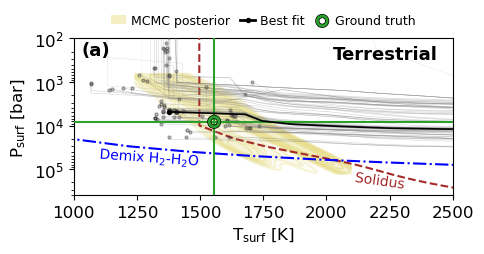

t_surf = 2038.89 (+115.11 -244.21)
p_surf = 87981.34 (+70510.47 -74500.78)
r_phot = 1.44 (+0.07 -0.11)
BO objectives range from -8.085 to -0.171
    best worker 61 with objective -0.171
    final point: 426.74, 0.84
Ground truth final: 1828.39, 35296.61, 1.46


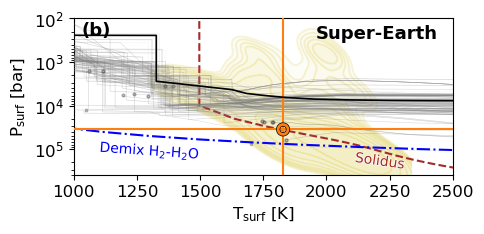

t_surf = 1737.73 (+132.75 -121.73)
p_surf = 15481.92 (+30806.80 -12138.25)
r_phot = 1.87 (+0.09 -0.08)
BO objectives range from -2.340 to -0.346
    best worker 95 with objective -0.346
    final point: 1625.55, 11989.72
Ground truth final: 1796.64, 22271.20, 1.92


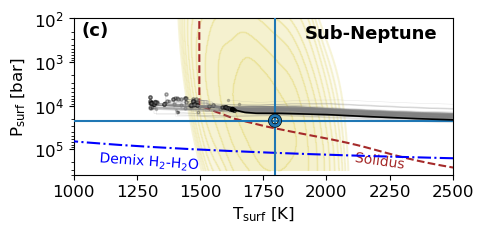

In [81]:
iplt =0

def comp_evol_stat(suf):
    global iplt

    outdir_planet = gt_ret[suf]["outdir"]
    keys = gt_ret[suf]["keys"]
    samples = gt_ret[suf]["samples"]

    samps = pd.read_csv(os.path.join(outdir_planet,"result.csv"),skiprows=1, sep=",", encoding="utf-8")
    truth = pd.read_csv(os.path.join(outdir_planet,"truth.csv") ,skiprows=1, sep=",", encoding="utf-8")

    ntruth = len(truth)

    # get last samples from samps
    end_frac = 0.1
    nsamp = int(len(samps)*end_frac)
    samps = samps.iloc[-nsamp:]

    ckey = "r_phot"   ; cfmt = "%.2f"

    xkey = "t_surf" ; xfmt = "%.2f"
    xlabel = r"T$_{\rm surf}$ [K]"
    xmin = 1000
    xmax = 2500

    ylabel = r"P$_{\rm surf}$ [bar]"
    ykey = "p_surf"; yfmt = "%.2f"
    ymin = 1e2
    ymax = 4e5

    fig,ax = plt.subplots(1,1,figsize=(5,2.5))

    al = 0.2
    ms = 3

    if ia.util.varprops[ckey].log:
        c = 10**(samps[ckey].values)
    else:
        c = samps[ckey].values
    mask = np.argsort(c)[::-1]

    x = ia.util.nondimen(samps[xkey].iloc[mask], xkey)
    y = ia.util.nondimen(samps[ykey].iloc[mask], ykey)
    c = ia.util.nondimen(c[mask], ckey)
    c = np.nan_to_num(c, nan=np.nanmax(c))

    # mcmc result
    x_med = np.median(x); x_err=[  [np.median(x)-np.percentile(x, 16)], [np.percentile(x, 84)-np.median(x)]]
    print(xkey + " = "+str(xfmt)%x_med + " (+"+str(xfmt)%x_err[1][0] + " -"+str(xfmt)%x_err[0][0] + ")")
    y_med = np.median(y); y_err=[ [np.median(y)-np.percentile(y, 16)], [np.percentile(y, 84)-np.median(y)],]
    print(ykey + " = "+str(yfmt)%y_med + " (+"+str(yfmt)%y_err[1][0] + " -"+str(yfmt)%y_err[0][0] + ")")
    c_med = np.median(c); c_err=[[np.median(c)-np.percentile(c, 16)], [np.percentile(c, 84)-np.median(c)]]
    print(ckey + " = "+str(cfmt)%c_med + " (+"+str(cfmt)%c_err[1][0] + " -"+str(cfmt)%c_err[0][0] + ")")

    # show mcmc output as scatter
    # ax.scatter(x,y, color='grey', 
    #            s=ms,  alpha=al, 
    #            edgecolors="none", rasterized=True)

    # show mcmc output as KDE
    _kde2d(ax, x, y, log_x=ia.util.varprops[xkey].log, log_y=ia.util.varprops[ykey].log,
           n_levels=10, zorder=1, col="#e8de88", label="MCMC posterior")

    # samples from BO runs
    obj_min = np.amin([obj for obj in bo_data[suf]["objectives"] if obj > -15])
    obj_max = np.amax(bo_data[suf]["objectives"])
    print(f"BO objectives range from {obj_min:.3f} to {obj_max:.3f}")
    # cmap = deepcopy(plt.get_cmap("Reds"))
    # boundaries = np.linspace(obj_min, obj_max, 7)
    # norm = mpl.colors.BoundaryNorm(boundaries=boundaries, ncolors=cmap.N)
    # sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    # cbar = fig.colorbar(sm, ax=ax, label="Objective", pad=0.01, extend='min', aspect=9)
    # cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%+.1f'))

    for i in range(len(bo_data[suf]["helps"])):
        hf_all = bo_data[suf]["helps"][i]
        
        xrun_arr = [key_map(xkey, row) for _, row in hf_all.iterrows()]
        yrun_arr = [key_map(ykey, row) for _, row in hf_all.iterrows()]

        # get alpha from normalised objective value
        obj = bo_data[suf]["objectives"][i]
        if obj<-15:
            continue

        alpha = 0.4 * (obj - obj_min) / (obj_max - obj_min)
        zo = 9
        color = 'grey'
        ms = 6*alpha

        # is best?
        if bo_data[suf]["is_best"][i]:
            color = 'k'
            alpha = 1.0
            zo = 10
            ms *= 1.2
            lbl = "Best fit"
            print(f"    best worker {i} with objective {obj:.3f}")
            print("    final point: "+str(xfmt)%xrun_arr[-1]+", "+str(yfmt)%yrun_arr[-1])
        else:
            lbl = ""

        ax.plot(xrun_arr, yrun_arr, lw=1.2*alpha, 
                color=color, alpha=alpha, zorder=zo)
        
        # end point
        ax.plot([xrun_arr[-1]], [yrun_arr[-1]],  markersize=ms,  marker='o',
                   alpha=alpha, color=color, zorder=zo, lw=2,
                   markeredgecolor="k", label=lbl)

    # ground truth evolution model, loop through rows to make path
    hf_all = ground_truth[suf]["help"]
    xtruth_arr = [key_map(xkey, row) for _, row in hf_all.iterrows()]
    ytruth_arr = [key_map(ykey, row) for _, row in hf_all.iterrows()]
    ctruth_arr = [key_map(ckey, row) for _, row in hf_all.iterrows()]
    ctruth_color = bo_cols[suf]
    xtruth_fin = xtruth_arr[-1]
    ytruth_fin = ytruth_arr[-1]
    ax.scatter(xtruth_fin, ytruth_fin, color='none', edgecolor=ctruth_color, s=50, zorder=10, lw=2,
               label="Ground truth",
                path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])
    ax.axhline(y=ytruth_fin, color=ctruth_color, linestyle='-', linewidth=1.5, zorder=9)
    ax.axvline(x=xtruth_fin, color=ctruth_color, linestyle='-', linewidth=1.5, zorder=9)
    print("Ground truth final: "+str(xfmt)%xtruth_fin+", "+str(yfmt)%ytruth_fin+", "+str(cfmt)%ctruth_arr[-1])

    # add melting curves
    meltkeys = {"solidus": "brown"}#, "liquidus": "goldenrod"}
    for (curve, color) in meltkeys.items():
        pmc,tmc = meltcurves[curve]
        ax.plot(tmc, pmc, linestyle='--', linewidth=1.5,  zorder=4, color=color)
        txt_tmp = 2200.0
        ax.annotate(curve.capitalize(),
                     xy=(txt_tmp, pmc[np.argmin(np.abs(tmc - txt_tmp))]), 
                    xytext=(2, 0),
                    textcoords='offset points', ha='center', va='top',
                    color=color, fontsize=10, rotation=-8,
                    path_effects=[pe.Stroke(linewidth=1, foreground='w'), pe.Normal()])
    
    # add demixing binodal
    H2O_truth = key_map("vmr_H2O", ground_truth[suf]["help"].iloc[-1])
    tdm = calc_Tdemix(pmc, H2O_truth)
    ax.plot(tdm, pmc, linestyle='-.', linewidth=1.5, color='blue', zorder=4)
    txt_tmp = 1100.0
    txt_prs = pmc[np.argmin(np.abs(tdm - txt_tmp))]
    ax.annotate(r"Demix H$_2$-H$_2$O", xy=(txt_tmp, txt_prs), 
                xytext=(0, -5),
                textcoords='offset points', ha='left', va='top',
                color='blue', fontsize=10, rotation=-4,
                path_effects=[pe.Stroke(linewidth=1, foreground='w'), pe.Normal()])

    if ia.util.varprops[xkey].log:
        ax.set_xscale("log")
    if ia.util.varprops[ykey].log:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # xmin = min(np.percentile(x, 2),  np.amin(xtruth_arr))
    # xmax = max(np.percentile(x, 98), np.amax(xtruth_arr))
    # ymin = min(np.percentile(y, 2),  np.amin(ytruth_arr))
    # ymax = max(np.percentile(y, 98), np.amax(ytruth_arr))
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymax, ymin)


    ax.text(0.02,0.98, f"({abcd[iplt]})",  transform=ax.transAxes,
             ha="left", va="top", fontsize=13, fontweight="bold", zorder=999)
    ax.text(0.96,0.96, bo_tits[suf], transform=ax.transAxes,
            ha="right", va="top", fontsize=13, fontweight="bold", zorder=999)
    fig.tight_layout()

    if iplt == 0:
        ax.legend(loc="lower center", fontsize=9, frameon=False, 
                  bbox_to_anchor=(0.5, 1.0), ncol=3, 
                  columnspacing=0.8, handlelength=1.2, handletextpad=0.4)

    fig.savefig(os.path.join(f"output/{suf}_static.pdf"), dpi=DPI, bbox_inches="tight")
    plt.show()
    iplt += 1

iplot = 0
for suf in gt_ret.keys():
    comp_evol_stat(suf)
